   Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0      148             72             35        0  33.6   
1       85             66             29        0  26.6   
2      183             64              0        0  23.3   
3       89             66             23       94  28.1   
4      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


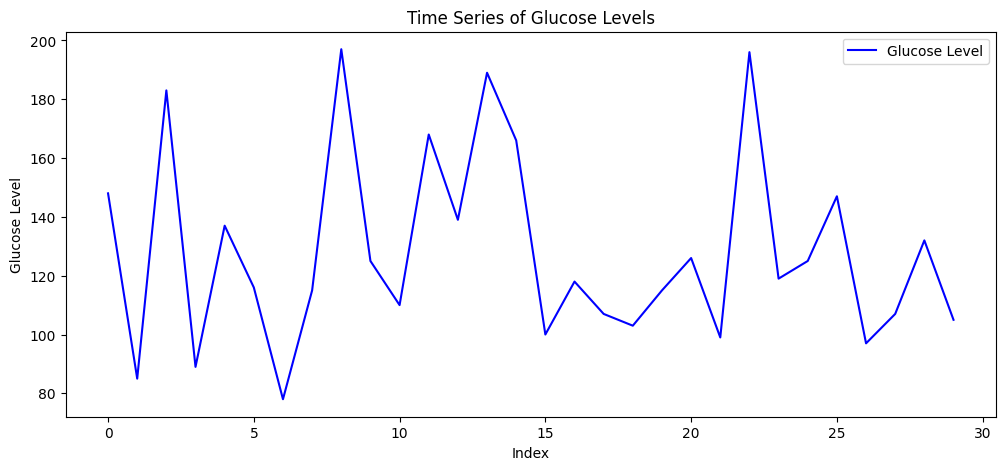

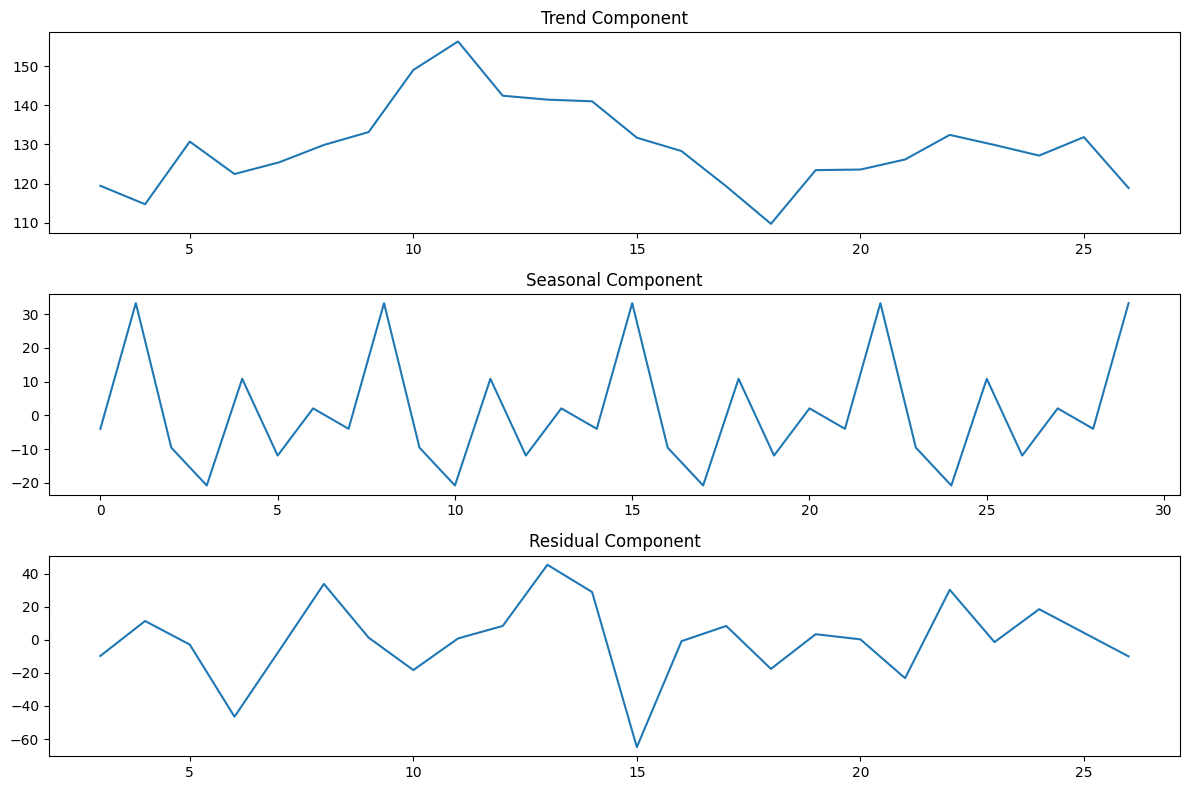

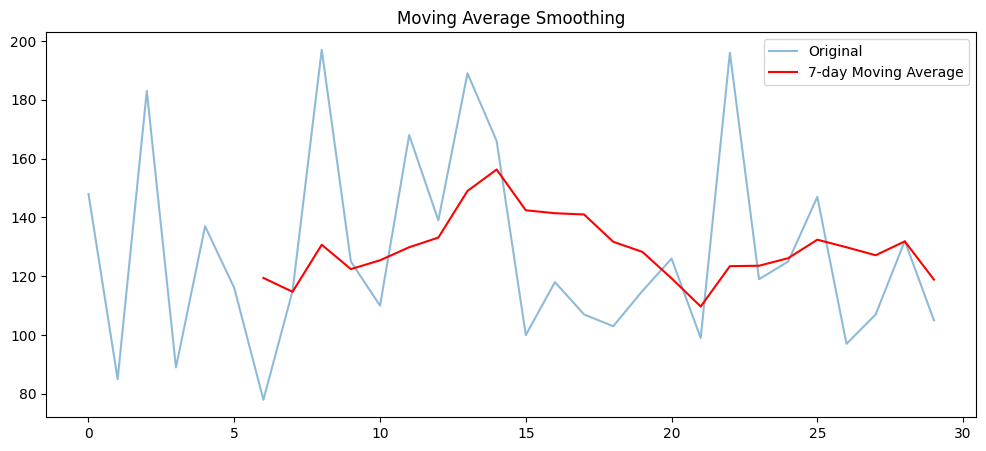

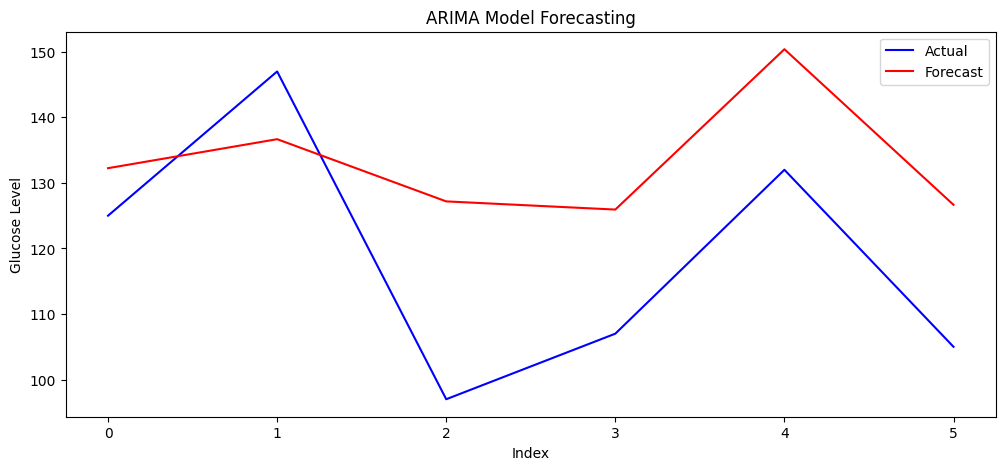

In [4]:
# Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA

# Load the Dataset
diabetes_data = pd.read_csv("uci_diabetes.csv")

# Check and Preview the Data
print(diabetes_data.head())

# Plot Time Series Data
plt.figure(figsize=(12, 5))
plt.plot(
    diabetes_data['Glucose'],
    label="Glucose Level",
    color='blue'
)
plt.xlabel("Index")
plt.ylabel("Glucose Level")
plt.title("Time Series of Glucose Levels")
plt.legend()
plt.show()

# Decompose Time Series into Trend, Seasonality, and Residuals
decomposition = seasonal_decompose(
    diabetes_data['Glucose'],
    model='additive',
    period=7
)

fig, axes = plt.subplots(3, 1, figsize=(12, 8))

decomposition.trend.plot(
    ax=axes[0],
    title="Trend Component"
)

decomposition.seasonal.plot(
    ax=axes[1],
    title="Seasonal Component"
)

decomposition.resid.plot(
    ax=axes[2],
    title="Residual Component"
)

plt.tight_layout()
plt.show()

# Apply Moving Average for Smoothing
diabetes_data['Glucose_MA'] = diabetes_data['Glucose'].rolling(
    window=7
).mean()

plt.figure(figsize=(12, 5))
plt.plot(
    diabetes_data['Glucose'],
    label="Original",
    alpha=0.5
)
plt.plot(
    diabetes_data['Glucose_MA'],
    label="7-day Moving Average",
    color='red'
)
plt.legend()
plt.title("Moving Average Smoothing")
plt.show()

# Build ARIMA Model for Forecasting
train_size = int(len(diabetes_data) * 0.8)

train = diabetes_data['Glucose'][:train_size]
test = diabetes_data['Glucose'][train_size:]

model = ARIMA(
    train,
    order=(5, 1, 0)
)  # ARIMA(p,d,q) where p=5, d=1, q=0

fitted_model = model.fit()

# Forecast Future Glucose Levels
forecast = fitted_model.forecast(
    steps=len(test)
)

# Plot Forecast vs Actual Data
plt.figure(figsize=(12, 5))

plt.plot(
    range(len(test)),
    test,
    label="Actual",
    color="blue"
)

plt.plot(
    range(len(test)),
    forecast,
    label="Forecast",
    color="red"
)

plt.xlabel("Index")
plt.ylabel("Glucose Level")
plt.title("ARIMA Model Forecasting")
plt.legend()
plt.show()